# Z_score (Anomalies detections algo)


## An Interactive Presentation

**Library:** `ifri_mini_ml_lib`

---

### Table of Contents
1. What is Z-Score?
2. Key Concepts
3. Why Modified Z-Score?
4. Implementation with `ifri_mini_ml_lib`
5. Comparison Between Both Implementations
6. Interactive Demo
7. Real-Life Applications
8. Limits and Challenges
9. Comparison between ifri_mini_ml_lib ans Scikit-learn
10. References

In [ ]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib.util
from ipywidgets import interact, FloatSlider, IntSlider
import warnings
warnings.filterwarnings('ignore')

# Le bon chemin
chemin_z_score = r"C:\Users\felic\Documents\ifri_mini_ml_lib\ifri_mini_ml_lib\anomalies_detection\z_score.py"

# Import du module personnalisé
spec = importlib.util.spec_from_file_location("z_score", chemin_z_score)
z_score = importlib.util.module_from_spec(spec)
spec.loader.exec_module(z_score)

zscore_detection = z_score.zscore_detection
modified_zscore_detection = z_score.modified_zscore_detection

print("Custom Z-Score module loaded successfully!")

# Scikit-learn imports
try:
    from sklearn.datasets import make_blobs
    from sklearn.preprocessing import StandardScaler
    print(" scikit-learn imported")
except ImportError:
    print(" scikit-learn not installed")

# Seaborn (optional)
try:
    import seaborn as sns
    HAS_SEABORN = True
    print(" seaborn imported")
except ImportError:
    HAS_SEABORN = False
    print(" seaborn not installed")

print("\n" + "=" * 50)
print("ALL READY!")
print("=" * 50)


plt.style.use('default')
if HAS_SEABORN:
    sns.set_palette("husl")

Custom Z-Score module loaded successfully!
✅ scikit-learn imported
 seaborn not installed

ALL READY!


## 1. What is Z-Score? 

### Definition
The **Z-Score** (also called **standard score**) is a statistical measurement that describes a value's relationship to the mean of a group of values.

### The Formula

$$ Z = \frac{X - \mu}{\sigma} $$

Where:
- **X** = The value to analyze
- **μ (mu)** = Mean of the dataset
- **σ (sigma)** = Standard deviation of the dataset

### Interpretation
| Z-Score | Meaning |
|---------|---------|
| Z = 0 | Value equals the mean |
| -1 < Z < 1 | Within 1 standard deviation (~68% of data) |
| -2 < Z < 2 | Within 2 standard deviations (~95% of data) |
| -3 < Z < 3 | Within 3 standard deviations (~99.7% of data) |
| \|Z\| > 3 | **ANOMALY** (outside 99.7% confidence interval) |

### Simple Example
If the average height of students is 170cm with a standard deviation of 10cm:
- A student of 190cm: Z = (190 - 170)/10 = **2.0** → Tall but normal
- A student of 210cm: Z = (210 - 170)/10 = **4.0** → **ANOMALY!** 

## 2. Key Concepts 

### 2.1 Normal Distribution (Gaussian)
The Z-Score assumes your data follows a **bell curve** (normal distribution).

```python
# Visual demonstration of normal distribution
x = np.linspace(-4, 4, 100)
y = 1/(np.sqrt(2*np.pi)) * np.exp(-x**2/2)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2)
plt.fill_between(x, y, where=(x >= -3) & (x <= 3), alpha=0.3, color='green', label='Normal region (99.7%)')
plt.fill_between(x, y, where=(x < -3) | (x > 3), alpha=0.3, color='red', label='Anomaly region (0.3%)')
plt.axvline(x=-3, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7)
plt.title('Normal Distribution with Anomaly Thresholds (|Z| > 3)')
plt.xlabel('Z-Score')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Why Modified Z-Score?

### The Problem with Classic Z-Score

The classic Z-Score uses **mean** and **standard deviation**, which are **sensitive to outliers**!

### Demonstration

DEMONSTRATION: Classic Z-Score vs Modified Z-Score
Total data points: 96
Normal points: 90
Outliers added: 6

CLASSIC STATISTICS (affected by outliers):
   Mean: 139.70
   Standard Deviation: 163.51

 ROBUST STATISTICS (resistant to outliers):
   Median: 99.75
   MAD (Median Absolute Deviation): 6.28



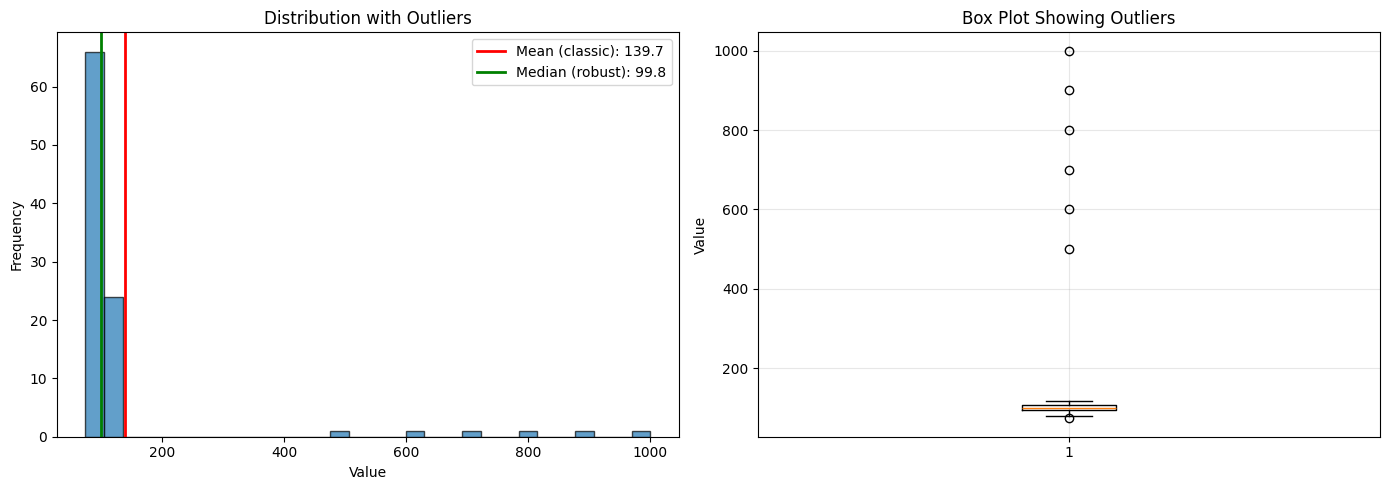

In [29]:
# Create data with extreme outliers
np.random.seed(42)
normal_data = np.random.normal(100, 10, 90)  # 90 normal points
outliers = np.array([500, 600, 700, 800, 900, 1000])  # 6 extreme outliers
data_with_outliers = np.concatenate([normal_data, outliers])

print("=" * 60)
print("DEMONSTRATION: Classic Z-Score vs Modified Z-Score")
print("=" * 60)
print(f"Total data points: {len(data_with_outliers)}")
print(f"Normal points: 90")
print(f"Outliers added: 6")
print()

# Calculate statistics
classic_mean = np.mean(data_with_outliers)
classic_std = np.std(data_with_outliers)
robust_median = np.median(data_with_outliers)
mad = np.median(np.abs(data_with_outliers - robust_median))

print(f"CLASSIC STATISTICS (affected by outliers):")
print(f"   Mean: {classic_mean:.2f}")
print(f"   Standard Deviation: {classic_std:.2f}")
print()
print(f" ROBUST STATISTICS (resistant to outliers):")
print(f"   Median: {robust_median:.2f}")
print(f"   MAD (Median Absolute Deviation): {mad:.2f}")
print()

# Visual comparison
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(data_with_outliers, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(classic_mean, color='red', linewidth=2, label=f'Mean (classic): {classic_mean:.1f}')
plt.axvline(robust_median, color='green', linewidth=2, label=f'Median (robust): {robust_median:.1f}')
plt.title('Distribution with Outliers')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
# Box plot to show outliers clearly
plt.boxplot(data_with_outliers, vert=True)
plt.title('Box Plot Showing Outliers')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### The Modified Z-Score Formula

$$ M_i = \frac{0.6745 \times (x_i - \text{median})}{\text{MAD}} $$

Where:
- **MAD** = Median(|x_i - median|) = Median Absolute Deviation
- **0.6745** = Conversion factor to make MAD comparable to standard deviation

### Why is it better?

| Feature | Classic Z-Score | Modified Z-Score |
|---------|-----------------|------------------|
| Central tendency | Mean (sensitive) | Median (robust)  |
| Dispersion | Std Deviation (sensitive) | MAD (robust)  |
| Outlier resistance | Low | High |
| Recommended threshold | 3.0 | 3.5 |

### When to use Modified Z-Score?
- When your data already contains anomalies
- When you have a small dataset (< 30 points)
- When your distribution is not perfectly normal
- In production systems where robustness is critical

## 4. Implementation with `ifri_mini_ml_lib` 

### Creating a Sample Dataset
Let's create a realistic dataset: **Temperature readings from a sensor**

DATASET: Sensor Temperature Readings
Total readings: 210
Normal readings: 200
Anomalies injected: 10
Temperature range: 12.0°C - 42.0°C
Mean temperature: 25.0°C


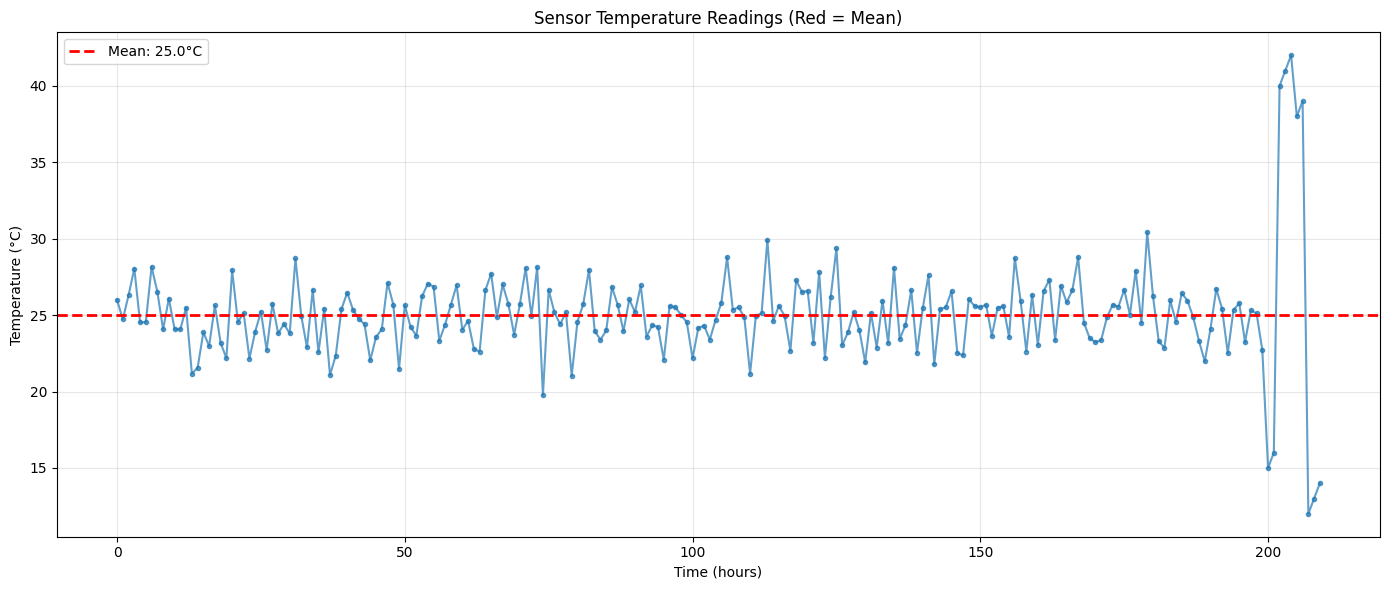

In [30]:
# Create realistic temperature data
np.random.seed(42)

# Normal temperatures (20°C to 30°C)
normal_temps = np.random.normal(25, 2, 200)

# Add some anomalies (sensor failures, extreme events)
anomalies = np.array([15, 16, 40, 41, 42, 38, 39, 12, 13, 14])

# Combine
temperatures = np.concatenate([normal_temps, anomalies])
timestamps = np.arange(len(temperatures))

print("=" * 60)
print("DATASET: Sensor Temperature Readings")
print("=" * 60)
print(f"Total readings: {len(temperatures)}")
print(f"Normal readings: {len(normal_temps)}")
print(f"Anomalies injected: {len(anomalies)}")
print(f"Temperature range: {temperatures.min():.1f}°C - {temperatures.max():.1f}°C")
print(f"Mean temperature: {np.mean(temperatures):.1f}°C")

# Visualize the dataset
plt.figure(figsize=(14, 6))
plt.plot(timestamps, temperatures, 'o-', markersize=3, alpha=0.7)
plt.axhline(y=np.mean(temperatures), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(temperatures):.1f}°C')
plt.title('Sensor Temperature Readings (Red = Mean)')
plt.xlabel('Time (hours)')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
print("=" * 60)
print("ANOMALY DETECTION with ifri_mini_ml_lib")
print("=" * 60)

# Classic Z-Score detection
classic_anomalies, classic_zscores = zscore_detection(
    temperatures, 
    threshold=3.0, 
    return_zscore=True
)

# Modified Z-Score detection
modified_anomalies, modified_zscores = modified_zscore_detection(
    temperatures, 
    threshold=3.5, 
    return_zscore=True
)

print(f"\n **CLASSIC Z-SCORE (threshold=3.0):")
print(f"   Anomalies detected: {sum(classic_anomalies)}")
print(f"   Anomaly positions: {np.where(classic_anomalies)[0].tolist()}")

print(f"\n **MODIFIED Z-SCORE (threshold=3.5):")
print(f"   Anomalies detected: {sum(modified_anomalies)}")
print(f"   Anomaly positions: {np.where(modified_anomalies)[0].tolist()}")

# Calculate detection rate
true_anomaly_positions = list(range(len(normal_temps), len(temperatures)))
detected_classic = sum([1 for pos in true_anomaly_positions if classic_anomalies[pos]])
detected_modified = sum([1 for pos in true_anomaly_positions if modified_anomalies[pos]])

print(f"\n **DETECTION RATE (on injected anomalies):")
print(f"   Classic Z-Score: {detected_classic}/{len(anomalies)} ({detected_classic/len(anomalies)*100:.0f}%)")
print(f"   Modified Z-Score: {detected_modified}/{len(anomalies)} ({detected_modified/len(anomalies)*100:.0f}%)")

ANOMALY DETECTION with ifri_mini_ml_lib

 **CLASSIC Z-SCORE (threshold=3.0):
   Anomalies detected: 8
   Anomaly positions: [202, 203, 204, 205, 206, 207, 208, 209]

 **MODIFIED Z-SCORE (threshold=3.5):
   Anomalies detected: 10
   Anomaly positions: [200, 201, 202, 203, 204, 205, 206, 207, 208, 209]

 **DETECTION RATE (on injected anomalies):
   Classic Z-Score: 8/10 (80%)
   Modified Z-Score: 10/10 (100%)


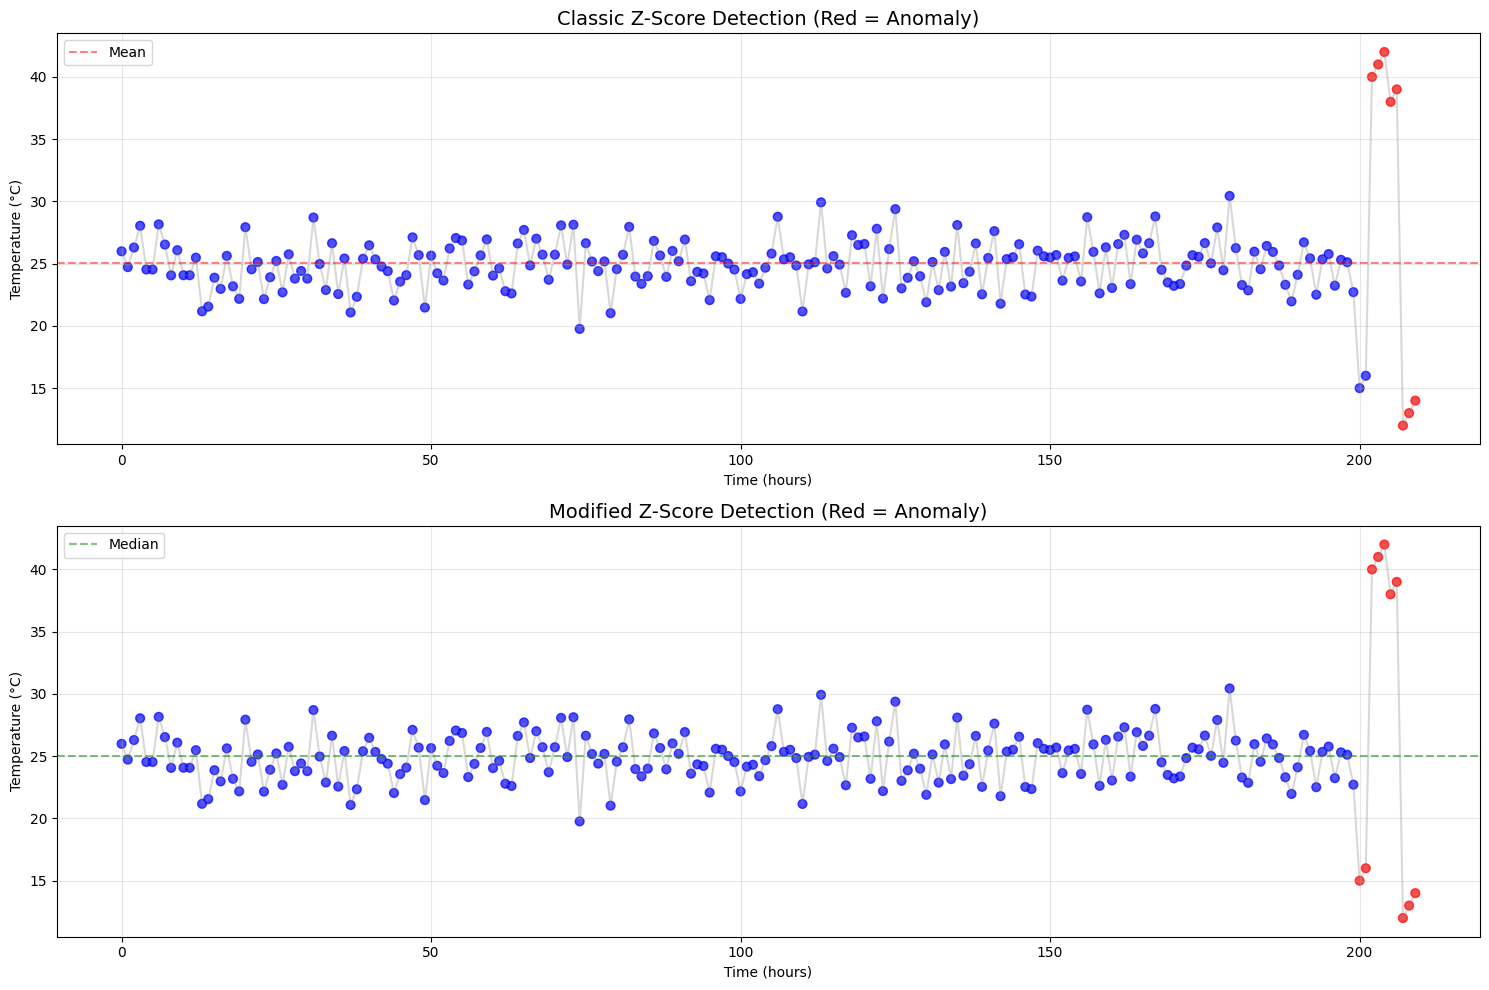

In [32]:
plt.figure(figsize=(15, 10))

# Plot 1: Original data with classic anomalies
plt.subplot(2, 1, 1)
colors_classic = ['red' if a else 'blue' for a in classic_anomalies]
plt.scatter(timestamps, temperatures, c=colors_classic, s=40, alpha=0.7)
plt.plot(timestamps, temperatures, 'gray', alpha=0.3)
plt.axhline(y=np.mean(temperatures), color='red', linestyle='--', alpha=0.5, label='Mean')
plt.title('Classic Z-Score Detection (Red = Anomaly)', fontsize=14)
plt.xlabel('Time (hours)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Modified anomalies
plt.subplot(2, 1, 2)
colors_modified = ['red' if a else 'blue' for a in modified_anomalies]
plt.scatter(timestamps, temperatures, c=colors_modified, s=40, alpha=0.7)
plt.plot(timestamps, temperatures, 'gray', alpha=0.3)
plt.axhline(y=np.median(temperatures), color='green', linestyle='--', alpha=0.5, label='Median')
plt.title('Modified Z-Score Detection (Red = Anomaly)', fontsize=14)
plt.xlabel('Time (hours)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Comparison: Classic vs Modified Z-Score 

### Performance Comparison on Different Data Types

COMPARISON TABLE: Classic vs Modified Z-Score
                Scenario  Data Size  Classic Anomalies  Modified Anomalies  Classic Rate (%)  Modified Rate (%)
Clean Data (No outliers)        200                  2                   1               1.0                0.5
      Few Outliers (2-3)        200                  3                   3               1.5                1.5
  Many Outliers (10-15%)        200                 11                  20               5.5               10.0
 Asymmetric Distribution        200                  0                  49               0.0               24.5


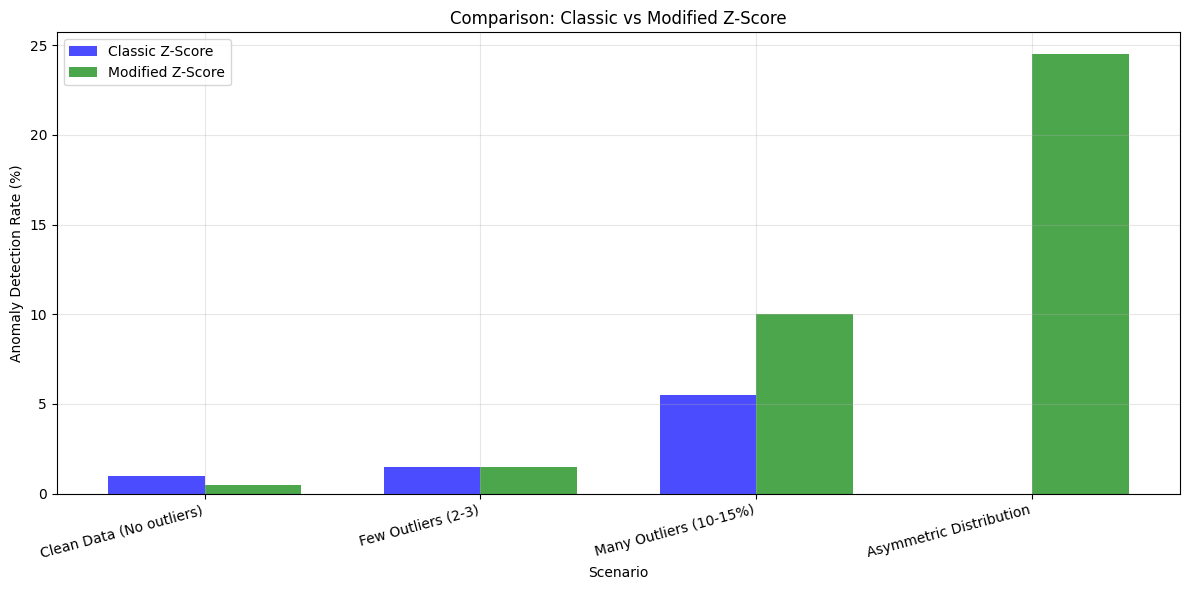

In [33]:
# Test different scenarios
scenarios = {
    "Clean Data (No outliers)": np.random.normal(100, 10, 200),
    "Few Outliers (2-3)": np.concatenate([np.random.normal(100, 10, 197), [300, 320, 310]]),
    "Many Outliers (10-15%)": np.concatenate([np.random.normal(100, 10, 180), np.random.uniform(200, 400, 20)]),
    "Asymmetric Distribution": np.concatenate([np.random.normal(80, 5, 150), np.random.normal(120, 5, 50)])
}

results = []

for name, data in scenarios.items():
    # Classic
    classic_anom = zscore_detection(data, threshold=3.0)
    # Modified
    modified_anom = modified_zscore_detection(data, threshold=3.5)
    
    results.append({
        "Scenario": name,
        "Data Size": len(data),
        "Classic Anomalies": sum(classic_anom),
        "Modified Anomalies": sum(modified_anom),
        "Classic Rate (%)": round(sum(classic_anom)/len(data)*100, 2),
        "Modified Rate (%)": round(sum(modified_anom)/len(data)*100, 2)
    })

# Create comparison DataFrame
comparison_df = pd.DataFrame(results)
print("=" * 70)
print("COMPARISON TABLE: Classic vs Modified Z-Score")
print("=" * 70)
print(comparison_df.to_string(index=False))

# Visualization
plt.figure(figsize=(12, 6))
x = np.arange(len(scenarios))
width = 0.35

plt.bar(x - width/2, comparison_df['Classic Rate (%)'], width, label='Classic Z-Score', color='blue', alpha=0.7)
plt.bar(x + width/2, comparison_df['Modified Rate (%)'], width, label='Modified Z-Score', color='green', alpha=0.7)

plt.xlabel('Scenario')
plt.ylabel('Anomaly Detection Rate (%)')
plt.title('Comparison: Classic vs Modified Z-Score')
plt.xticks(x, comparison_df['Scenario'], rotation=15, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Interactive Demo 

### Play with the parameters and see real-time anomaly detection!

**Instructions:**
- Adjust the **threshold** to make detection more or less sensitive
- Change the **anomaly value** to see when it becomes an outlier
- The plot updates automatically!

In [38]:
from ipywidgets import interact, FloatSlider, IntSlider, Checkbox

@interact(
    threshold=FloatSlider(min=1.0, max=5.0, step=0.1, value=3.0, description='Threshold:'),
    anomaly_value=IntSlider(min=50, max=500, step=10, value=300, description='Anomaly value:'),
    use_modified=Checkbox(value=False, description='Use Modified Z-Score')  # ← Correction ici !
)
def interactive_demo(threshold=3.0, anomaly_value=300, use_modified=False):
    # Create base data
    base_data = [100, 102, 98, 101, 99, 100, 101, 98, 102, 99, 100, 101]
    
    # Insert anomaly at position 5
    data_with_anomaly = base_data.copy()
    data_with_anomaly[5] = anomaly_value
    
    # Detect anomalies
    if use_modified:
        anomalies, zscores = modified_zscore_detection(data_with_anomaly, threshold=threshold, return_zscore=True)
        method_name = "Modified Z-Score"
        stat_line = f"Median: {np.median(data_with_anomaly):.1f}"
    else:
        anomalies, zscores = zscore_detection(data_with_anomaly, threshold=threshold, return_zscore=True)
        method_name = "Classic Z-Score"
        stat_line = f"Mean: {np.mean(data_with_anomaly):.1f}, Std: {np.std(data_with_anomaly):.1f}"
    
    is_anomaly = anomalies[5]
    
    # Display results
    print("=" * 60)
    print(f"METHOD: {method_name}")
    print("=" * 60)
    print(f"Data: {data_with_anomaly}")
    print(f"Anomaly at index 5: {anomaly_value}")
    print(f"Threshold: {threshold}")
    print(f"{stat_line}")
    print(f"Z-score of anomaly: {zscores[5]:.2f}")
    print(f"Is anomaly: {'YES' if is_anomaly else ' NO'}")
    
    if is_anomaly:
        print(f"\n The value {anomaly_value} is an ANOMALY because |{zscores[5]:.2f}| > {threshold}")
    else:
        print(f"\nThe value {anomaly_value} is NORMAL because |{zscores[5]:.2f}| < {threshold}")
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left plot: Data points with colors
    colors = ['red' if a else 'blue' for a in anomalies]
    ax1.scatter(range(len(data_with_anomaly)), data_with_anomaly, c=colors, s=100, zorder=5)
    ax1.plot(range(len(data_with_anomaly)), data_with_anomaly, 'gray', alpha=0.5)
    if use_modified:
        ax1.axhline(y=np.median(data_with_anomaly), color='green', linestyle='--', label='Median')
    else:
        ax1.axhline(y=np.mean(data_with_anomaly), color='red', linestyle='--', label='Mean')
    ax1.set_title(f'{method_name} - Anomaly Detection')
    ax1.set_xlabel('Index')
    ax1.set_ylabel('Value')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Right plot: Z-scores
    colors_z = ['red' if abs(z) > threshold else 'blue' for z in zscores]
    ax2.bar(range(len(zscores)), zscores, color=colors_z, alpha=0.7)
    ax2.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold: {threshold}')
    ax2.axhline(y=-threshold, color='red', linestyle='--')
    ax2.axhline(y=0, color='black', linewidth=0.5)
    ax2.set_title('Z-Scores')
    ax2.set_xlabel('Index')
    ax2.set_ylabel('Z-Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return is_anomaly

interactive(children=(FloatSlider(value=3.0, description='Threshold:', max=5.0, min=1.0), IntSlider(value=300,…

## 7. Real-Life Applications 

Z-Score anomaly detection is used across many industries:

| Industry | Application | Example |
|----------|-------------|---------|
|  **Finance** | Fraud detection | Unusually large transactions |
|  **IT/DevOps** | Server monitoring | CPU spikes, memory leaks |
|  **Manufacturing** | Quality control | Defective product dimensions |
|  **Automotive** | Predictive maintenance | Engine sensor anomalies |
|  **Healthcare** | Patient monitoring | Abnormal vital signs |
|  **Environment** | Climate monitoring | Extreme temperature events |
|  **Cybersecurity** | Intrusion detection | Unusual network traffic |
|  **Marketing** | Customer behavior | Unusual purchase patterns |

### Case Study: Credit Card Fraud Detection

```python
# Simulate credit card transactions
np.random.seed(42)

# Normal transactions: $20-$200
normal_transactions = np.random.normal(100, 40, 1000)
normal_transactions = np.clip(normal_transactions, 20, 500)

# Fraudulent transactions: $1000+
fraudulent = np.array([1500, 2300, 1800, 3200, 2900, 1100, 4500])

# Combine
all_transactions = np.concatenate([normal_transactions, fraudulent])

# Detect anomalies
anomalies, zscores = zscore_detection(all_transactions, threshold=3.0, return_zscore=True)

print("=" * 60)
print("CASE STUDY: Credit Card Fraud Detection")
print("=" * 60)
print(f"Total transactions: {len(all_transactions)}")
print(f"Normal transactions: {len(normal_transactions)}")
print(f"Fraudulent transactions: {len(fraudulent)}")
print(f"Fraudulent transactions flagged: {sum(anomalies[-len(fraudulent):])}")

fraud_detection_rate = sum(anomalies[-len(fraudulent):]) / len(fraudulent) * 100
print(f"\n Fraud detection rate: {fraud_detection_rate:.0f}%")

# Show the transactions
fraud_indices = np.where(anomalies)[0]
print(f"\n Flagged suspicious transactions: {fraud_indices.tolist()}")
print(f"   Amounts: {[all_transactions[i] for i in fraud_indices]}")

## 8. Limits and Challenges 

### 1. Assumes Normal Distribution
Z-Score works best when data follows a bell curve. For non-normal distributions, it may produce false positives.

### 2. Sensitive to Multiple Anomalies
Classic Z-Score can be "blinded" by multiple anomalies (masking effect).

### 3. Batch Processing Only
Z-Score typically requires the entire dataset; not ideal for real-time streaming.

### 4. No Seasonality or Trends
Cannot handle:
- Cyclical patterns (e.g., higher traffic on weekends)
- Trends (e.g., gradual temperature increase)

### 5. Threshold Selection
Choosing the right threshold (2.5, 3.0, or 4.0) is context-dependent and impacts performance.

### When NOT to use Z-Score:

| Scenario | Alternative |
|----------|-------------|
| Time series with trend | ARIMA, Prophet |
| Seasonal data | Seasonal Z-Score |
| Non-normal distribution | IQR (Interquartile Range) |
| High-dimensional data | Isolation Forest, DBSCAN |
| Streaming data | Online anomaly detection |

### The Masking Effect Demonstration

THE MASKING EFFECT DEMONSTRATION
Clean data: 0 anomalies (ideal)
Corrupted data (with 11 outliers): 5 anomalies detected
 Only 5 out of 11 outliers identified!

The mean and standard deviation are skewed by the outliers,
causing the anomalies to appear less extreme!


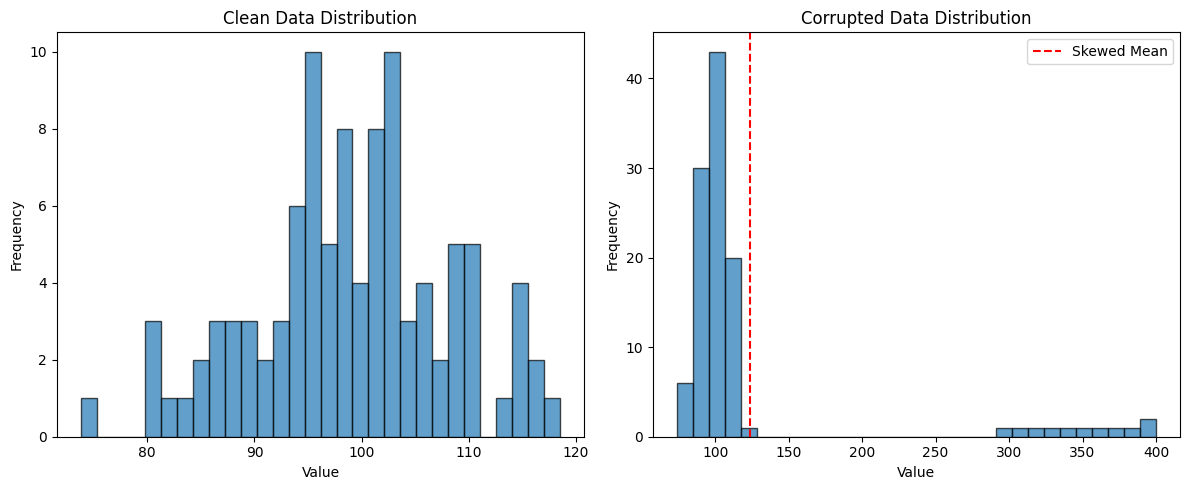

In [39]:
# Demonstrate the masking effect
np.random.seed(42)

# Clean data
clean_data = np.random.normal(100, 10, 100)
clean_anomalies = zscore_detection(clean_data, threshold=3.0)

# Data with multiple anomalies
anomalies_list = [300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400]
corrupted_data = np.concatenate([clean_data, anomalies_list])
corrupted_anomalies = zscore_detection(corrupted_data, threshold=3.0)

print("=" * 60)
print("THE MASKING EFFECT DEMONSTRATION")
print("=" * 60)
print(f"Clean data: {sum(clean_anomalies)} anomalies (ideal)")
print(f"Corrupted data (with 11 outliers): {sum(corrupted_anomalies)} anomalies detected")
print(f" Only {sum(corrupted_anomalies[-len(anomalies_list):])} out of {len(anomalies_list)} outliers identified!")
print("\nThe mean and standard deviation are skewed by the outliers,")
print("causing the anomalies to appear less extreme!")

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(clean_data, bins=30, edgecolor='black', alpha=0.7)
plt.title('Clean Data Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(corrupted_data, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(np.mean(corrupted_data), color='red', linestyle='--', label='Skewed Mean')
plt.title('Corrupted Data Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# 9.Comparison between ifri_mini_ml_lib and Scikit-learn

In [ ]:
import sys
import os
import time
import numpy as np
import pandas as pd

sys.path.insert(0, r"C:\Users\felic\Documents\ifri_mini_ml_lib\ifri_mini_ml_lib\anomalies_detection")

# Import direct de ton module
from z_score import zscore_detection


# Import of scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import EllipticEnvelope

print("=" * 70)
print("COMPARAISON: ifri_mini_ml_lib vs scikit-learn")
print("=" * 70)

# 1. Creation of the dataset

print("\n1. Creation of the dataset")
print("-" * 50)

np.random.seed(42)
n_samples = 10000
n_outliers = 500

# Normal data 
normal_data = np.random.normal(100, 15, n_samples - n_outliers)

# Anomalies(extrems values)
outliers = np.random.uniform(200, 500, n_outliers)

# Concatenate and shuffle
data = np.concatenate([normal_data, outliers])
np.random.shuffle(data)

print(f"Number of samples: {len(data)}")
print(f"Number of outliers: {n_outliers}")
print(f"Percentage of anomalies: {n_outliers/len(data)*100:.1f}%")
print(f"Range of values: [{data.min():.1f}, {data.max():.1f}]")
print(f"Mean: {data.mean():.1f}")
print(f"Standard deviation: {data.std():.1f}")

# 2. Implementation with ifri_mini_ml_lib

print("\n\n 2. Detection with ifri_mini_ml_lib")
print("-" * 50)

# Measure the execution time
start_time = time.time()

# Detection with classic Z-score
anomalies_maison, z_scores = zscore_detection(
    data, 
    threshold=3.0, 
    return_zscore=True
)

end_time = time.time()
time_maison = end_time - start_time

print(f" Detection finished")
print(f"Execution time: {time_maison*1000:.2f} ms")
print(f" Anomalies detected: {sum(anomalies_maison)}")
print(f" Detection rate: {sum(anomalies_maison)/len(data)*100:.2f}%")

# 3. Implementation with scikit-learn

print("\n\n 3. Detection with scikit-learn ")
print("-" * 50)

# For scikit-learn, we need a 2D matrix
data_2d = data.reshape(-1, 1)

# Standardisation of the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_2d)

# Measure the execution time
start_time = time.time()

# EllipticEnvelope (equivalent of the multivariate Z-score)
elliptic = EllipticEnvelope(
    contamination=0.05,  # Proportion of expected anomalies
    random_state=42
)
predictions = elliptic.fit_predict(data_scaled)

# -1 = anomalie, 1 = normal
anomalies_sklearn = predictions == -1

end_time = time.time()
time_sklearn = end_time - start_time

print(f"Detection finished")
print(f" Execution time: {time_sklearn*1000:.2f} ms")
print(f" Anomalies detected: {sum(anomalies_sklearn)}")
print(f" Detection rate: {sum(anomalies_sklearn)/len(data)*100:.2f}%")

# 4. COMPARISON OF RESULTS
# ============================================================================

print("\n\n 4. COMPARISON OF RESULTS")
print("=" * 70)

comparaison = pd.DataFrame({
    'Metric': [
                'Anomalies detected',
                'Detection rate (%)',
                'Execution time (ms)',
                'Speed (samples/sec)'
    ],
    'ifri_mini_ml_lib': [
        f"{sum(anomalies_maison)}",
        f"{sum(anomalies_maison)/len(data)*100:.2f}%",
        f"{time_maison*1000:.2f}",
        f"{len(data)/time_maison:.0f}"
    ],
    'scikit-learn': [
        f"{sum(anomalies_sklearn)}",
        f"{sum(anomalies_sklearn)/len(data)*100:.2f}%",
        f"{time_sklearn*1000:.2f}",
        f"{len(data)/time_sklearn:.0f}"
    ]
})

print(comparaison.to_string(index=False))

# Calculation of the speedup
speedup = time_sklearn / time_maison
print(f"\n ifri_mini_ml_lib is {speedup:.1f} as fast as scikit-learn !")

# 5. Intersection of detected anomalies

print("\n\n 5. Intersection of detected anomalies")
print("-" * 50)

# Calculation of the intersection
both_detected = anomalies_maison & anomalies_sklearn
only_maison = anomalies_maison & ~anomalies_sklearn
only_sklearn = ~anomalies_maison & anomalies_sklearn

print(f" Detected by both methods: {sum(both_detected)} anomalies")
print(f" Detected UNIQUELY by ifri_mini_ml_lib: {sum(only_maison)} anomalies")
print(f" Detected UNIQUELY by scikit-learn: {sum(only_sklearn)} anomalies")

# Agreement rate
accord = sum(both_detected) / sum(anomalies_maison | anomalies_sklearn) * 100
print(f"Agreement rate between the two methods: {accord:.1f}%")



COMPARAISON: ifri_mini_ml_lib vs scikit-learn

1. Creation of the dataset
--------------------------------------------------
Total d'échantillons: 10000
Nombre d'anomalies réelles: 500
Pourcentage d'anomalies: 5.0%
Plage des valeurs: [42.5, 499.6]
Moyenne: 112.4
Écart-type: 59.3


 2. Detection with ifri_mini_ml_lib
--------------------------------------------------
 Detection finished
Execution time: 0.32 ms
 Anomalies detected: 340
 Detection rate: 3.40%


 3. Detection with scikit-learn (EllipticEnvelope)
--------------------------------------------------
Detection finished
 Execution time: 5.01 ms
 Anomalies detected: 500
 Detection rate: 5.00%


 4. COMPARISON OF RESULTS
             Metric ifri_mini_ml_lib scikit-learn
 Anomalies detected              340          500
 Detection rate (%)            3.40%        5.00%
Execution time (ms)             0.32         5.01
Speed (samples/sec)         30795184      1994154

 ifri_mini_ml_lib is 15.4 as fast as scikit-learn !


 5. Inters

## 10. References 

### Academic References

1. **Aggarwal, C. C. (2017).**  
   *Outlier Analysis* (2nd ed.). Springer.  
   ISBN: 978-3-319-47578-3

2. **Iglewicz, B., & Hoaglin, D. C. (1993).**  
   *How to Detect and Handle Outliers*.  
   ASQC Quality Press. ISBN: 978-0873891680

3. **Grubbs, F. E. (1969).**  
   Procedures for Detecting Outlying Observations in Samples.  
   *Technometrics*, 11(1), 1-21.

### Online Resources

- [NIST/SEMATECH e-Handbook of Statistical Methods](https://www.itl.nist.gov/div898/handbook/)
- [Scikit-learn Outlier Detection Documentation](https://scikit-learn.org/stable/modules/outlier_detection.html)

### Software & Libraries

- `ifri_mini_ml_lib` - Custom implementation ([GitHub](https://github.com/IFRI-AI-Classes/ifri_mini_ml_lib))
- `scikit-learn` - Machine learning library
- `NumPy` - Numerical computing
- `Matplotlib` - Visualization
- `pandas` - Data manipulation

### About This Implementation

This notebook uses the custom `ifri_mini_ml_lib` library, which implements:
- `zscore_detection()` - Classic Z-Score method
- `modified_zscore_detection()` - Robust Modified Z-Score with Median and MAD

---

## Thank You! 